In [72]:
import pandas as pd
import numpy as np
import mne
import os

In [62]:
import mne
print(mne.__version__)



1.12.1


In [63]:
eeg_df = pd.read_csv("offline_2back_sham.csv")
full_eeg_df = pd.read_csv("offline_2back_sham.csv")
full_eeg_df.drop(['Time', ' Ch08'], axis = 1, inplace = True)
full_eeg_df

,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07
0,-43745.968750,-90054.648438,-96530.523438,2154.469971,-90810.164062,-44963.605469,-43845.519531
1,-45293.335938,-89654.046875,-96594.414062,1629.781860,-90186.773438,-46047.710938,-45723.730469
2,-46425.656250,-90015.875000,-96968.726562,1299.262329,-90561.851562,-46726.898438,-46250.636719
3,-44949.582031,-90330.125000,-96877.984375,1767.635498,-91075.812500,-45698.292969,-44528.730469
4,-43675.398438,-90129.226562,-96554.187500,2179.026855,-90943.046875,-44899.230469,-43664.863281
...,...,...,...,...,...,...,...
49740,-60765.843750,-102492.601562,-111593.539062,-15888.333984,-105135.234375,-59842.738281,-59195.761719
49741,-60548.886719,-102734.859375,-111708.984375,-15843.250000,-105367.562500,-59828.687500,-59246.167969
49742,-60606.648438,-101624.109375,-111095.851562,-15986.396484,-103994.960938,-59968.957031,-60424.593750
49743,-60808.875000,-101210.960938,-110888.273438,-16054.989258,-103558.046875,-60003.781250,-60565.480469


In [64]:
markers = pd.read_csv("lifu_markers_1_2back_sham.csv")
lifu_on = markers[markers["marker"]=="LIFU_ON"].copy()
lifu_on_time_onset = np.array(lifu_on['Time'])
lifu_on_time_onset

array([ 57.0829887,  72.7382817,  87.748421 , 103.0673615, 118.5132294,
       155.2029245, 175.6946256, 191.4040139])

In [103]:
lifu_on_time_onset[0]

57.08298870001454

Creating RawArray with float64 data, n_channels=7, n_times=49745
    Range : 0 ... 49744 =      0.000 ...   198.976 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenua

C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\3559662716.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


Applying a custom ('EEG',) reference.
Fitting ICA to data using 7 channels (please be patient, this may take a while)
Selecting by explained variance: 6 components
Fitting ICA took 0.3s.


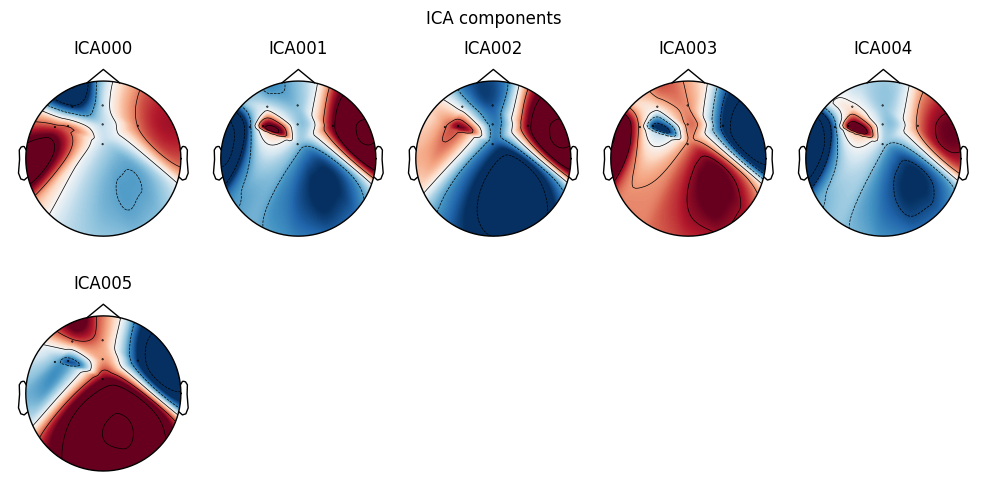

Creating RawArray with float64 data, n_channels=6, n_times=49745
    Range : 0 ... 49744 =      0.000 ...   198.976 secs
Ready.


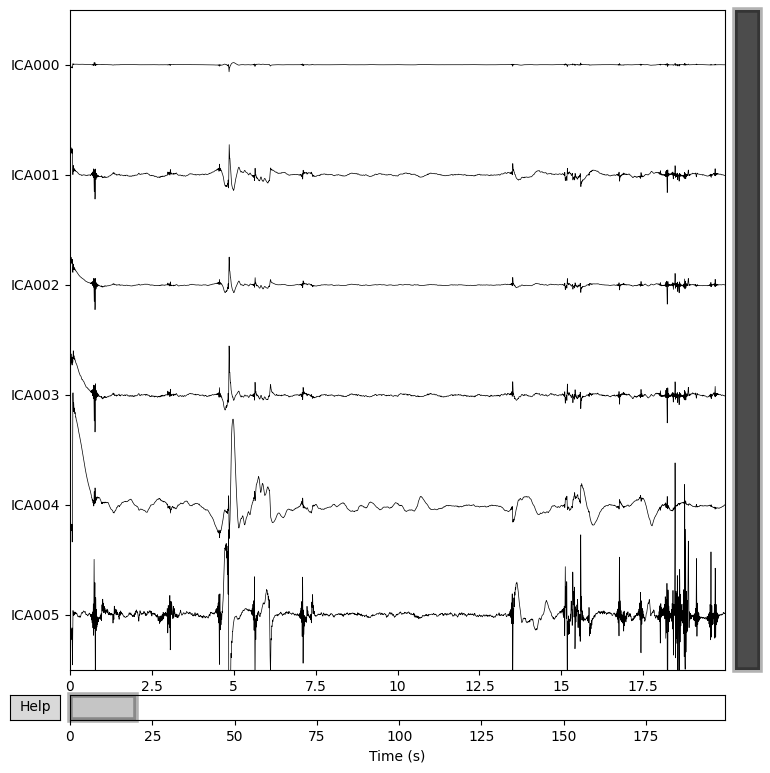

Applying ICA to Raw instance
    Transforming to ICA space (6 components)
    Zeroing out 2 ICA components
    Projecting back using 7 PCA components


In [81]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data

df = pd.DataFrame(full_eeg_df.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping --> make it less manual
ch_names = [
    "Fz",   # 1
    "FC3",   # 2
    "FC5",  # 3
    "F3",   # 4
    "FC4",   # 5
    "FCz",  # 6
    "Cz",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
#raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# Inspect components:
ica.plot_components()      # scalp maps
ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0,1]  # don't know how to do this
raw_clean = ica.apply(raw.copy())



In [106]:
# lifu_on_time_onset is an array of times in seconds
event_samples = (lifu_on_time_onset * raw.info['sfreq']).astype(int)

# Build MNE event array: shape (n_events, 3)
# Columns: [sample_index, 0, event_id]
events = np.column_stack([event_samples, 
                          np.zeros_like(event_samples, dtype=int), 
                          np.ones_like(event_samples, dtype=int)])
tmin = -2.0
tmax = 7.0

epochs = mne.Epochs(
    raw,
    events,
    event_id=1,
    tmin=tmin,
    tmax=tmax,
    baseline=None,     # or (-2, 0) if you want baseline correction
    preload=True
)


Not setting metadata
8 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 8 events and 2251 original time points ...
0 bad epochs dropped


In [109]:
epochs.get_data().shape # (n_sonications, n_channels, n_times)

(8, 7, 2251)

In [82]:
def rebuild_clean_df_and_window(raw_clean, original_df, event_times, pre=2, post=10):
    """
    raw_clean: your preprocessed MNE Raw object (filtered, ICA-cleaned, reref)
    original_df: the original pandas EEG dataframe with the 'Time' column
    event_times: list/array of absolute LSL timestamps (e.g., LIFU onset times)
    pre, post: window lengths in seconds
    """

    data = raw_clean.get_data().T   # shape (n_samples, n_channels)
    sfreq = raw_clean.info['sfreq']
    n_samples = data.shape[0]

    # original_df["Time"].iloc[0] = absolute LSL timestamp of sample 0
    t0 = original_df["Time"].iloc[0]
    time_axis = t0 + np.arange(n_samples) / sfreq

    ch_names = raw_clean.info['ch_names']
    clean_df = pd.DataFrame(data, columns=ch_names)
    clean_df["Time"] = time_axis

    windows = []

    for idx, event in enumerate(event_times):
        mask = (clean_df["Time"] >= (event - pre)) & (clean_df["Time"] <= (event + post))
        window_df = clean_df.loc[mask].copy()

        # Add relative time and index
        window_df["t_rel"] = window_df["Time"] - event
        window_df["idx"] = idx

        windows.append(window_df)

    return clean_df, windows
clean_df, raw_windows = rebuild_clean_df_and_window(
    raw_clean=raw_clean,
    original_df=eeg_df,
    event_times=lifu_on_time_onset,
    pre=2,
    post=10
)

# Example: inspect window 1
raw_windows[0]

,Fz,FC3,FC5,F3,FC4,FCz,Cz,Time,t_rel,idx
13771,2.366092,-30.764749,-23.765867,68.147913,-23.832793,6.995262,0.854142,55.084,-1.998989,0
13772,0.314803,-22.937137,-26.963970,65.645435,-15.980530,3.932487,-4.011088,55.088,-1.994989,0
13773,-0.792971,-20.753551,-27.755992,65.452129,-13.952101,2.776724,-4.974238,55.092,-1.990989,0
13774,-0.634821,-24.887600,-25.306720,67.213369,-18.035779,3.832893,-2.181341,55.096,-1.986989,0
13775,-0.505709,-29.799426,-21.907648,68.932364,-22.476699,4.971224,0.785894,55.100,-1.982989,0
...,...,...,...,...,...,...,...,...,...,...
16766,21.776795,-36.401547,-63.180591,73.285145,-30.941853,16.720345,18.741707,67.064,9.981011,0
16767,25.325199,-49.258072,-55.257367,75.880967,-43.456798,22.085881,24.680189,67.068,9.985011,0
16768,25.090870,-50.180355,-55.353730,76.857218,-44.502982,22.099491,25.989488,67.072,9.989011,0
16769,22.472405,-43.503673,-58.949517,75.679657,-37.466330,18.664270,23.103187,67.076,9.993011,0


In [73]:
base_dir_raw = r"C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw"
# MAKE SURE TO PUT IN NAME
new_folder_name = "sham1"
new_folder_path_raw = os.path.join(base_dir_raw, new_folder_name)
os.makedirs(new_folder_path_raw, exist_ok=False) # check

for idx, event in enumerate(raw_windows):
    # Build a unique filename for each event
    output_path_raw = os.path.join(new_folder_path_raw, f"{idx}_eeg_cleaned.csv")
    try:
        raw_windows[idx].to_csv(output_path_raw, index=False, encoding="utf-8")
        print(f"Saved successfully to: {output_path_raw}")
    except (OSError, IOError) as e:
        print(f"Error saving CSV file: {e}")

Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\0_eeg_cleaned.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\1_eeg_cleaned.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\2_eeg_cleaned.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\3_eeg_cleaned.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\4_eeg_cleaned.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\5_eeg_cleaned.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\6_eeg_cleaned.csv
Saved successfully to: C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\sham1\7_eeg_cleaned.csv


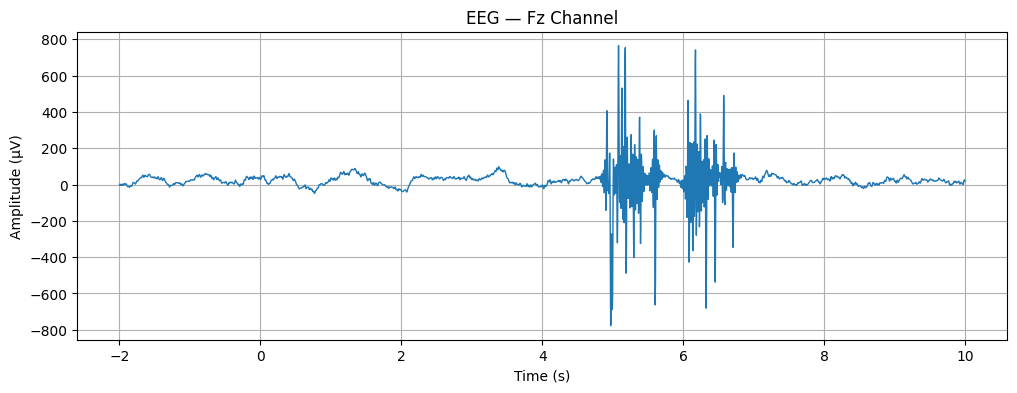

In [102]:
import matplotlib.pyplot as plt

df = raw_windows[0].copy()   # choose any window

time = df["t_rel"].to_numpy()      # time axis
fz = df["Cz"].to_numpy()           # first channel

plt.figure(figsize=(12,4))
plt.plot(time, fz, linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title("EEG — Fz Channel")
plt.grid(True)
plt.show()


Number of frequencies: 129
Number of time steps: 47


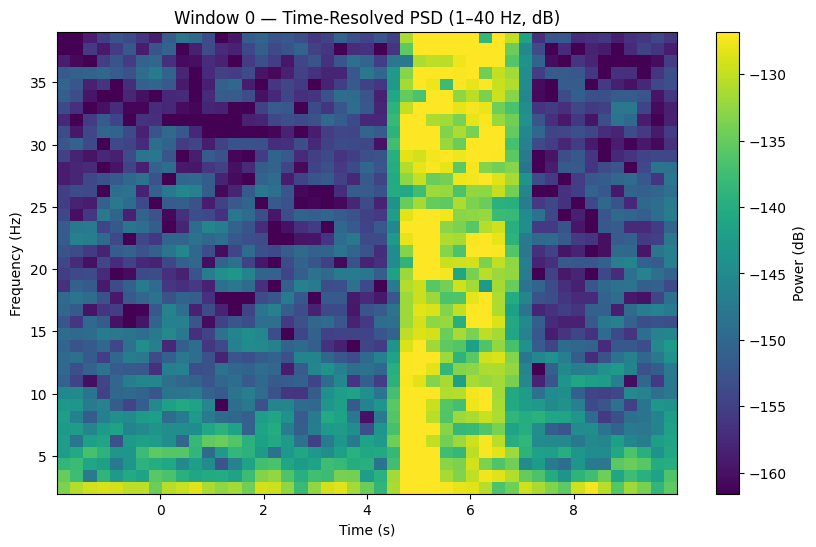

Number of frequencies: 129
Number of time steps: 47


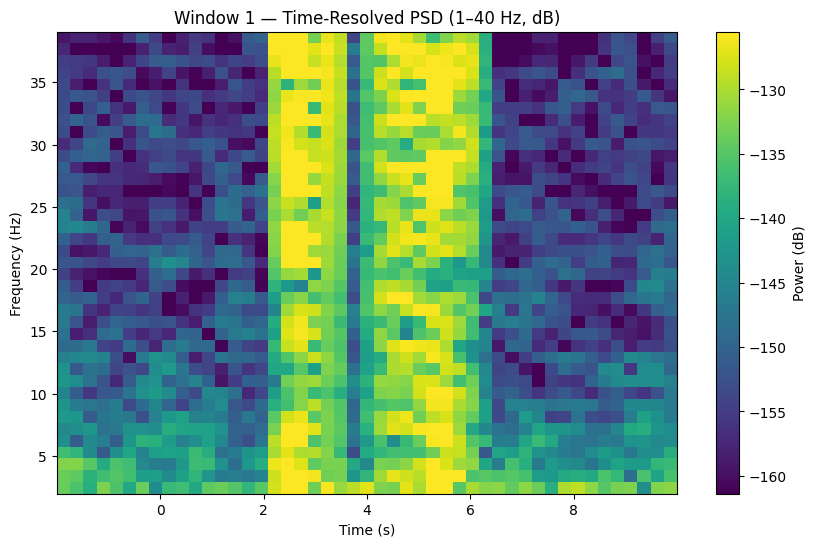

Number of frequencies: 129
Number of time steps: 47


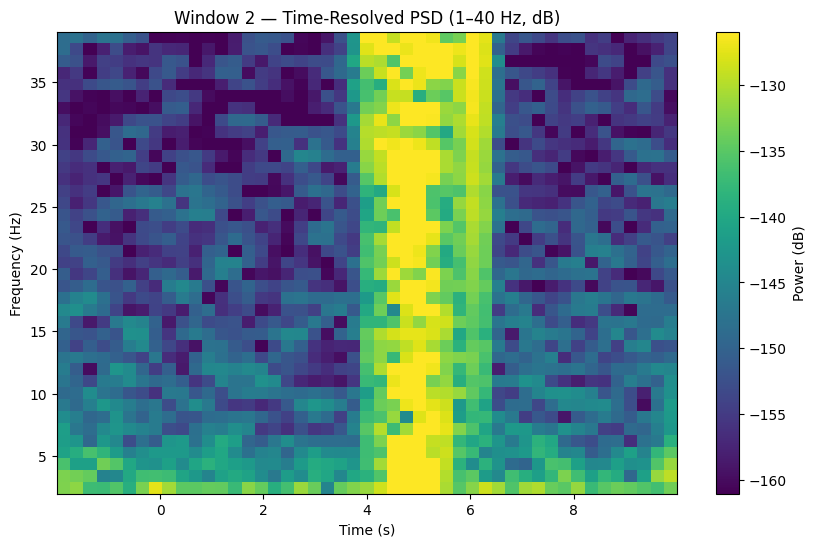

Number of frequencies: 129
Number of time steps: 47


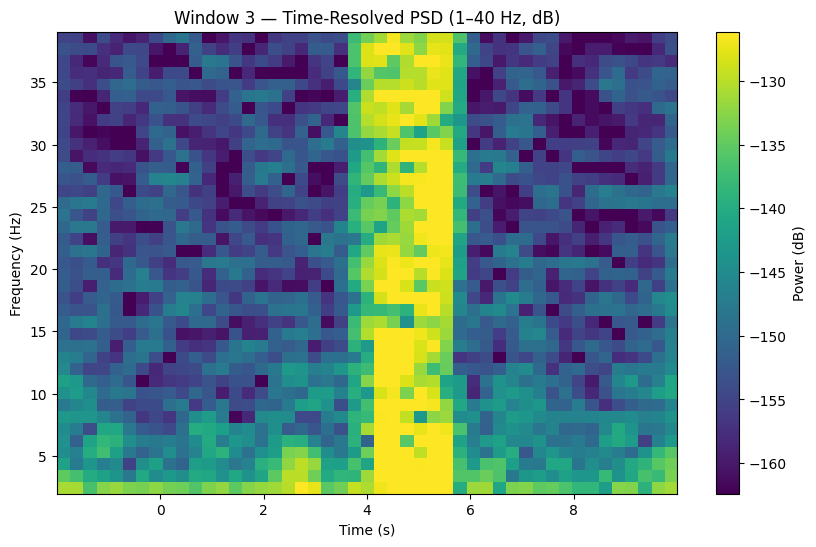

Number of frequencies: 129
Number of time steps: 47


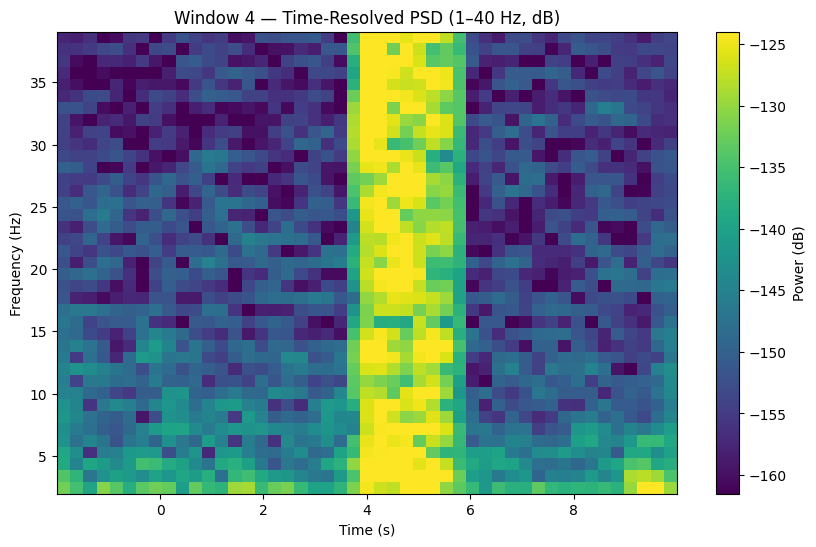

Number of frequencies: 129
Number of time steps: 47


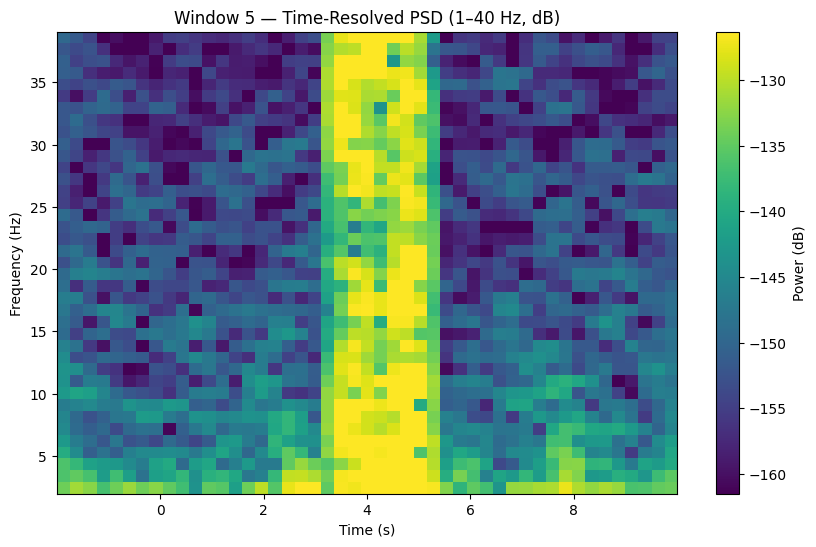

Number of frequencies: 129
Number of time steps: 47


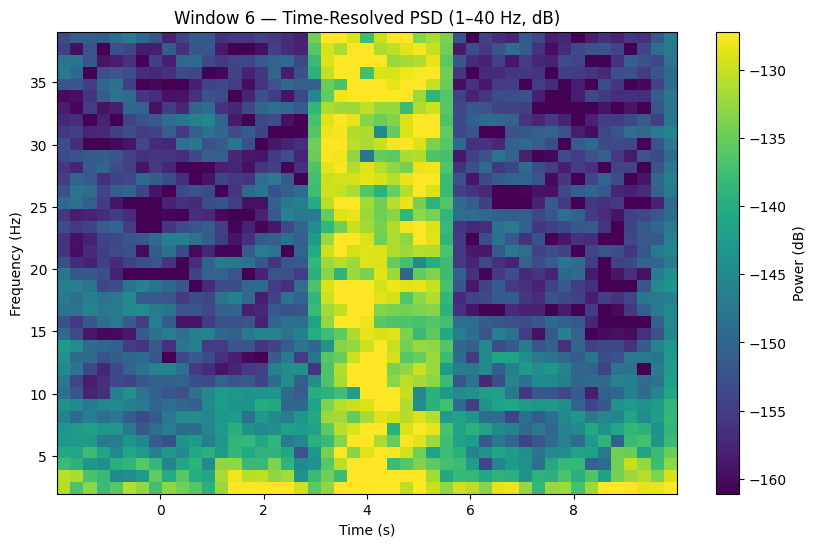

Number of frequencies: 129
Number of time steps: 38


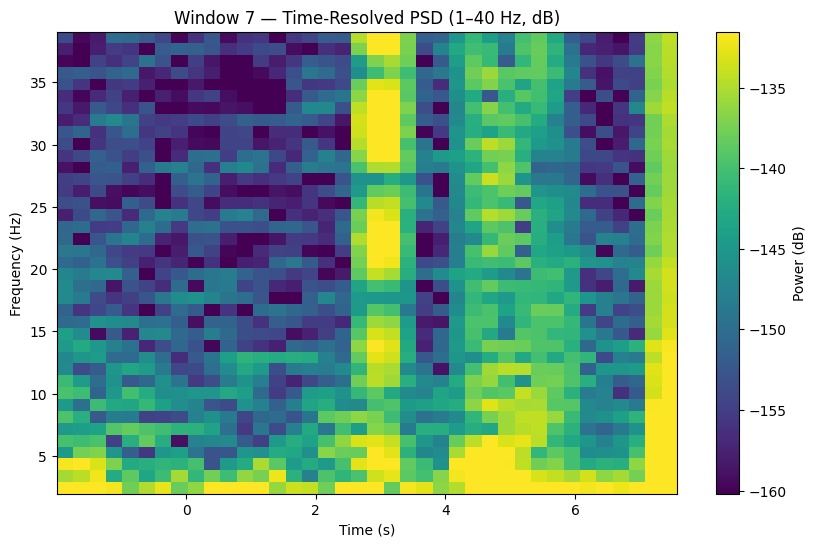

In [89]:
from mne.time_frequency import stft
import numpy as np
import matplotlib.pyplot as plt
import mne

sfreq = 250
ch_names = ["Fz", "FC3", "FC5", "F3", "FC4", "FCz", "Cz"]

all_spectrograms = []
all_times = []
all_freqs = []

for idx in range(len(raw_windows)):

    # --- Extract data ---
    df = raw_windows[idx].copy()
    mne_time = df["t_rel"].to_numpy()

    df.drop(['Time', 't_rel', 'idx'], axis=1, inplace=True)
    data = df.values.T * 1e-6   # µV → V

    # --- STFT parameters ---
    n_fft = 256
    step = 64

    # --- Compute STFT ---
    Zxx = stft(data, wsize=n_fft, tstep=step)
    power = np.abs(Zxx)**2

    # --- Normalize STFT (important!) ---
    power = power / (n_fft**2)

    # --- Build time axis ---
    times = np.linspace(mne_time[0], mne_time[-1], power.shape[-1])

    # --- Build frequency axis ---
    freqs = np.linspace(0, sfreq/2, power.shape[1])

    # --- Select 1–40 Hz ---
    mask = (freqs >= 1) & (freqs <= 40)
    freqs_1_40 = freqs[mask]
    power_1_40 = power[:, mask, :]

    # --- Average across channels ---
    psd_avg = power_1_40.mean(axis=0)

    # --- Convert to dB ---
    psd_db = 10 * np.log10(psd_avg + 1e-20)

    # --- Clip color range to avoid "all purple" ---
    vmin = np.percentile(psd_db, 5)
    vmax = np.percentile(psd_db, 95)

    # --- Store results ---
    all_spectrograms.append(psd_db)
    all_times.append(times)
    all_freqs.append(freqs_1_40)

    # --- Plot ---
    plt.figure(figsize=(10,6))
    plt.imshow(
        psd_db,
        aspect='auto',
        origin='lower',
        extent=[times[0], times[-1], freqs_1_40[0], freqs_1_40[-1]],
        vmin=vmin,
        vmax=vmax,
        cmap='viridis'
    )
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(f"Window {idx} — Time‑Resolved PSD (1–40 Hz, dB)")
    plt.colorbar(label="Power (dB)")
    plt.show()


Creating RawArray with float64 data, n_channels=7, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    11.996 secs
Ready.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\2334407320.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = spectrum.plot(


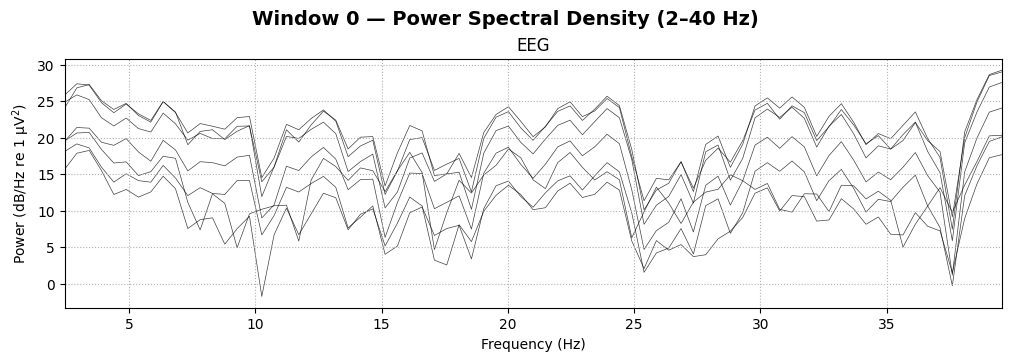

Creating RawArray with float64 data, n_channels=7, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    11.996 secs
Ready.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\2334407320.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = spectrum.plot(


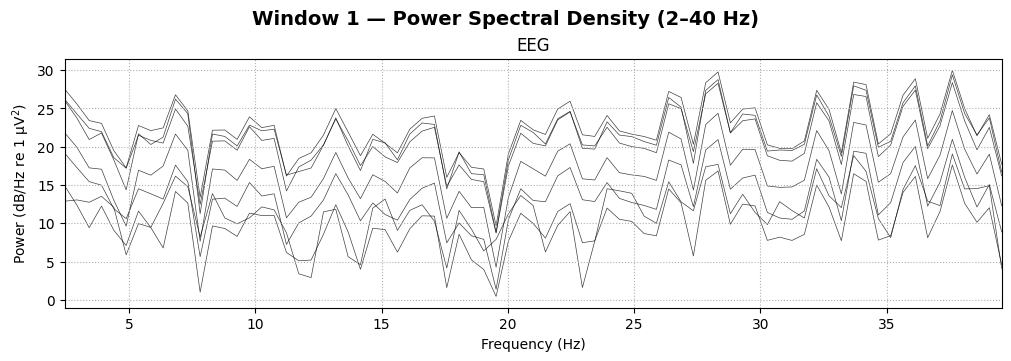

Creating RawArray with float64 data, n_channels=7, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    11.996 secs
Ready.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\2334407320.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = spectrum.plot(


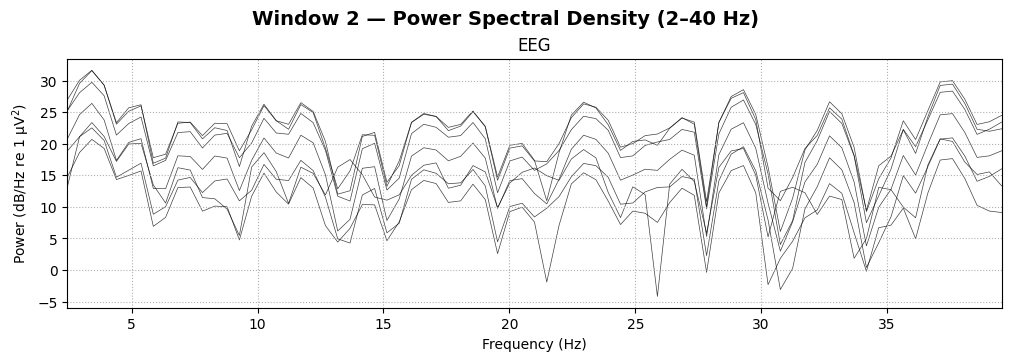

Creating RawArray with float64 data, n_channels=7, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    11.996 secs
Ready.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\2334407320.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = spectrum.plot(


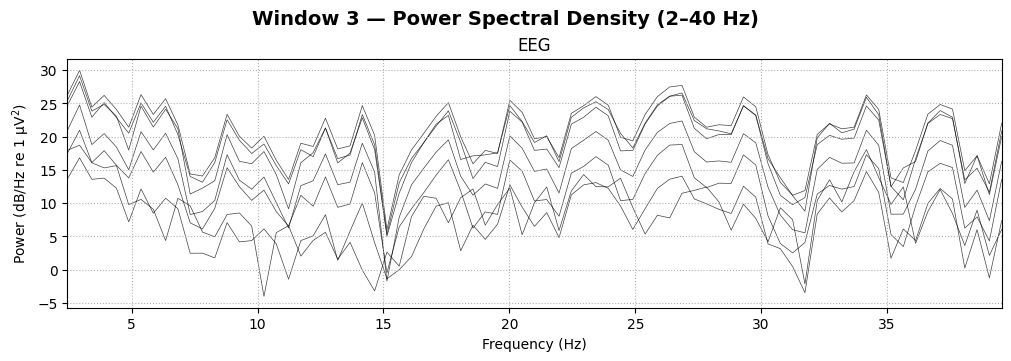

Creating RawArray with float64 data, n_channels=7, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    11.996 secs
Ready.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\2334407320.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = spectrum.plot(


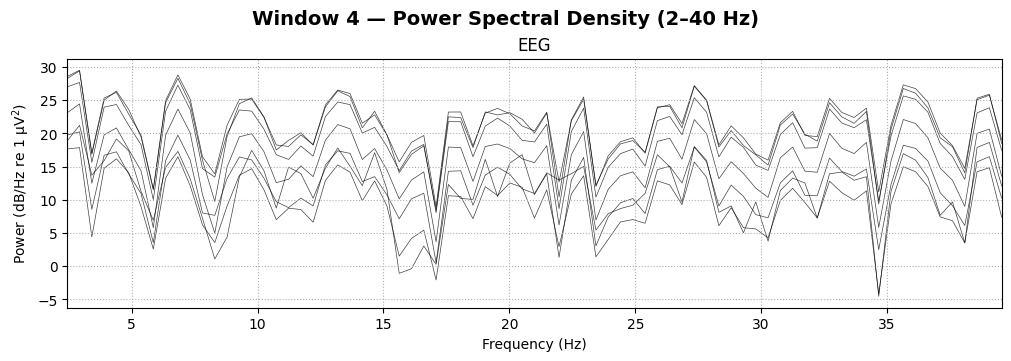

Creating RawArray with float64 data, n_channels=7, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    11.996 secs
Ready.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\2334407320.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = spectrum.plot(


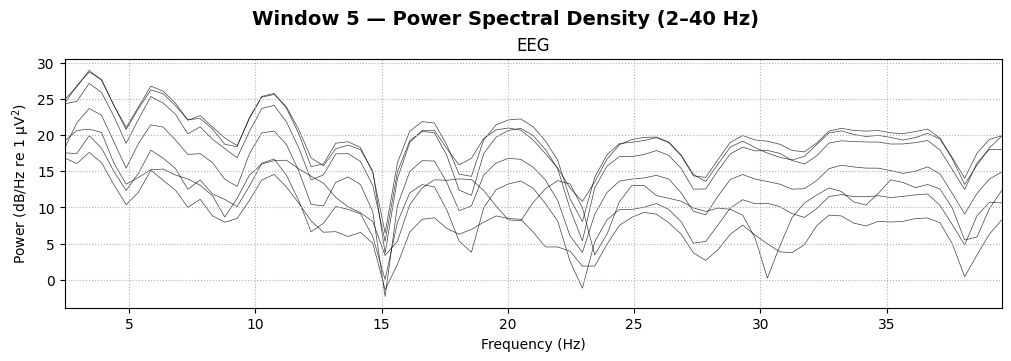

Creating RawArray with float64 data, n_channels=7, n_times=3000
    Range : 0 ... 2999 =      0.000 ...    11.996 secs
Ready.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\2334407320.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = spectrum.plot(


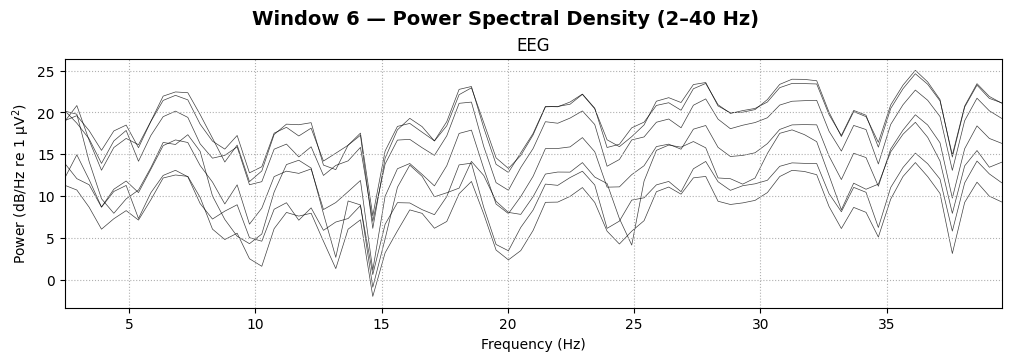

Creating RawArray with float64 data, n_channels=7, n_times=2393
    Range : 0 ... 2392 =      0.000 ...     9.568 secs
Ready.
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Temp\ipykernel_32288\2334407320.py:25: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  fig = spectrum.plot(


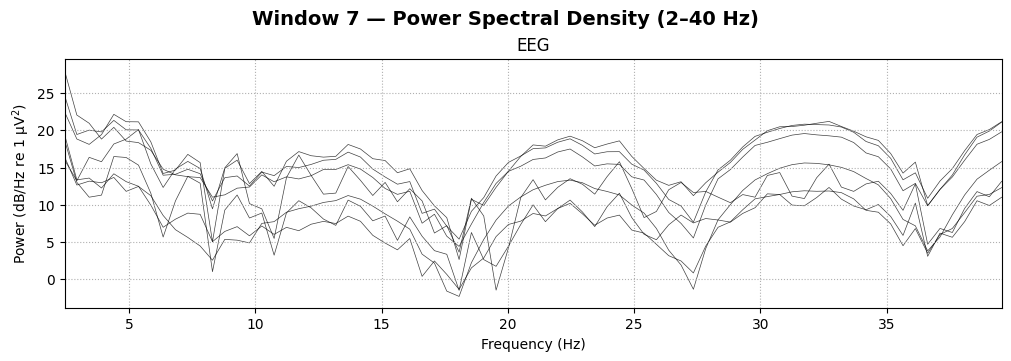

In [75]:
import mne
import numpy as np
import matplotlib.pyplot as plt

sfreq = 250
ch_names = ["Fz", "FC3", "FC5", "F3", "FC4", "FCz", "Cz"]

for idx in range(len(raw_windows)):

    # --- Extract window ---
    df = raw_windows[idx].copy()
    df.drop(['Time', 't_rel', 'idx'], axis=1, inplace=True)

    # Convert to volts
    data = df.values.T * 1e-6   # (n_channels, n_samples)

    # --- Build RawArray ---
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    raw = mne.io.RawArray(data, info)

    # --- Compute PSD ---
    spectrum = raw.compute_psd(fmin=2, fmax=40, n_fft=512)

    # --- Plot ---
    fig = spectrum.plot(
        picks='all',
        spatial_colors=True,
        exclude='bads',
        show=False
    )

    fig.suptitle(f'Window {idx} — Power Spectral Density (2–40 Hz)',
                 fontsize=14, weight='bold')

    plt.show()


In [76]:
raw.get_data().shape

(7, 2393)

In [83]:
# PSD DATA ANALYSIS
# Part 1: percent change pre and post trigger

fs = 250
prev = 2
posts = 10
pre_window = int(prev*fs)
post_window = int(posts* fs)
eeg_filt = pd.DataFrame(raw.get_data().copy()).T
#target_timestamp
pre_segments = []
post_segments  = []
pre_segments.append(eeg_filt.iloc[:pre_window])
post_segments.append(eeg_filt.iloc[pre_window:])

In [84]:
from scipy.signal import welch
import numpy as np

def compute_psd(seg):
    f, psd = welch(seg, fs=fs, nperseg=fs, axis=0)
    return f, psd  # psd shape: freqs × channels
pre_psds  = []
post_psds = []

for pre, post in zip(pre_segments, post_segments):
    f, pre_psd  = compute_psd(pre)
    f, post_psd = compute_psd(post)
    pre_psds.append(pre_psd)
    post_psds.append(post_psd)
pre_psd_mean  = np.mean(pre_psds, axis=0)
post_psd_mean = np.mean(post_psds, axis=0)


In [85]:
percent_change_psd = (post_psd_mean - pre_psd_mean) / pre_psd_mean *100
percent_change_psd = pd.DataFrame(percent_change_psd)
percent_change_psd

,0,1,2,3,4,5,6
0,2993.842239,22893.267389,45300.945203,2.064901e+06,10460.499971,15575.877236,3929.878050
1,1266.611551,4569.028973,16992.687796,9.019305e+04,19791.878961,21073.922627,3218.229142
2,28242.071849,26345.941018,208318.969983,2.544026e+05,22576.354138,79768.408220,18951.485532
3,12684.092141,33542.626030,81913.628078,3.369586e+05,30983.437738,41123.585054,9825.931283
4,11913.148338,36063.816075,50265.817737,4.590266e+05,51234.841791,40036.195424,12069.750091
...,...,...,...,...,...,...,...
121,-30.826930,-45.364740,-62.991442,1.568569e+02,-36.377655,205.098818,-30.225400
122,58.481479,-72.335845,-78.824320,6.629021e+02,-61.696667,412.087712,-71.940419
123,8.512799,-76.799261,-84.141056,6.420569e+02,-69.697432,319.334539,-76.441165
124,-24.981190,-82.933296,-87.940090,1.323049e+03,-77.664928,190.166683,-81.198013


In [86]:
def band_power(psd, freqs, f_lo, f_hi):
    idx = (freqs >= f_lo) & (freqs <= f_hi)
    return np.trapz(psd[idx, :], freqs[idx], axis=0)
# Theta (4–7 Hz)
pre_theta  = band_power(pre_psd_mean,  f, 4, 7)
post_theta = band_power(post_psd_mean, f, 4, 7)

# Alpha (8–12 Hz)
pre_alpha  = band_power(pre_psd_mean,  f, 8, 12)
post_alpha = band_power(post_psd_mean, f, 8, 12)

# Beta (13–30 Hz)
pre_beta  = band_power(pre_psd_mean,  f, 13, 30)
post_beta = band_power(post_psd_mean, f, 13, 30)

# Gamma (30-40Hz)
pre_gamma = band_power(pre_psd_mean,  f, 30, 40)
post_gamma = band_power(post_psd_mean, f, 30, 40)


theta_pct = (post_theta - pre_theta) / pre_theta * 100
alpha_pct = (post_alpha - pre_alpha) / pre_alpha * 100
beta_pct  = (post_beta  - pre_beta ) / pre_beta  * 100
gamma_pct =  (post_gamma  - pre_gamma ) / pre_gamma  * 100

bands_pct_df = pd.DataFrame({
    "Theta %Δ": theta_pct,
    "Alpha %Δ": alpha_pct,
    "Beta %Δ":  beta_pct,
    "Gamma %Δ" : gamma_pct,
})
bands_pct_df.index = [f"Ch{i+1}" for i in range(7)]
bands_pct_df


,Theta %Δ,Alpha %Δ,Beta %Δ,Gamma %Δ
Ch1,18582.379713,29138.681624,30465.723138,1905.457203
Ch2,69565.560396,131588.203597,141288.077279,3355.546982
Ch3,72033.561179,107353.946948,224954.041641,10988.479947
Ch4,330827.728800,205323.292124,47336.321043,6802.069221
Ch5,55245.251459,87831.072179,108862.663645,2197.348584
Ch6,64111.301214,120512.447525,152467.842228,7602.990163
Ch7,17719.745030,26705.725283,33856.548324,1718.513104
